## "Welcome to the world of AI" 
### Understanding temperature, top_p and top_k 

This post is part of a 4 part series on learning and building a decoder-only transformer from scratch. This is the first post that focuses on learning about **temperature**, **top_p** and **top_k** as they are used in language models.

Without further ado, let's move ahead.

In [13]:
# import the libraries.
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import softmax

In [14]:
# Let get our logits
# Freeze the random number generator
np.random.seed(0)

# call this our logits.
# As in the output from the model
logits = np.random.uniform(low=-5, high=5, size=(10)).round(2)
print(f'Logits: {logits}')

# Get the probabilities
probs = softmax(logits).round(2)
print(f'Probabilities : {probs.round(2)}')

Logits: [ 0.49  2.15  1.03  0.45 -0.76  1.46 -0.62  3.92  4.64 -1.17]
Probabilities : [0.01 0.05 0.02 0.01 0.   0.02 0.   0.29 0.59 0.  ]


In [15]:
# Create a function to visualize our logits and probs
def my_plots(plot1=logits, plot2=probs, plot1_title='', plot2_title=''):
    # Visualize the logits
    plt.figure(figsize=(12,4))
    plt.subplot(121)
    plt.title(plot1_title)
    plt.ylabel('logits')
    plt.xlabel('index position of logits')
    plt.xticks(ticks=range(0,len(plot1),1))
    #plt.yticks(ticks=range(len(logits)), labels=[ f'{v:.2f}' for v in logits ])
    plt.bar(x=range(0,len(plot1),1), height=plot1)
    plt.grid(axis='y');

    # Visualize the probabilities
    plt.subplot(122)
    plt.title(plot2_title)
    plt.bar(x=range(0,len(plot2),1), height=plot2)
    plt.ylabel('probabilities')
    plt.xlabel('index position of probs')
    #plt.yticks(ticks=probs)
    plt.xticks(ticks=range(0,len(plot2),1))
    plt.grid(axis='y');

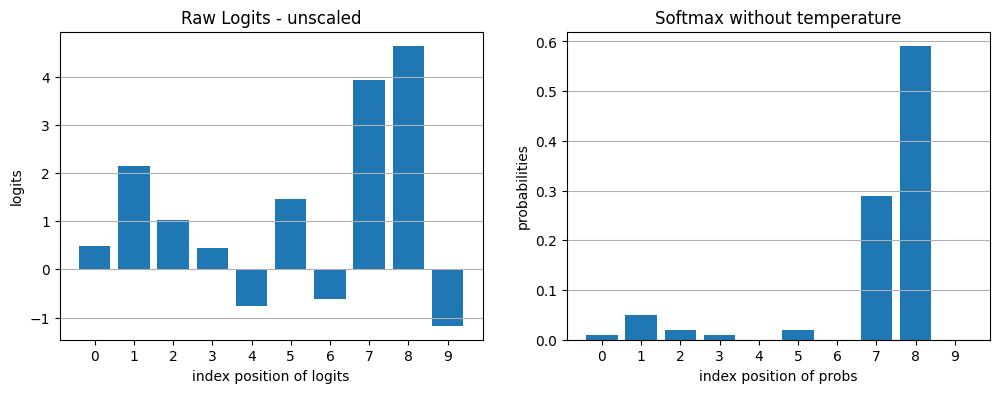

In [16]:
# Plot of the logits and softmax without temperature, top_p or top_k
my_plots(plot1=logits, plot2=probs, plot1_title='Raw Logits - unscaled', plot2_title='Softmax without temperature')

In your neural networks, the last layer produces the logits - left graph. These logits are the raw output from the network (wx+b) before any activations. These logits then are passed through an activation function, generally Softmax - multiple class prediction - or Sigmoid - binary classification. Above, once we pass the logits through the Softmax, we see the probabilities distribution of the logits. The largest logit corresponds to the largest probability. This tells us that for the item at position 8, the model has high - 0.6 or 60% - confidence that the item is in this class. If we were working with predicting MNIST digits, the model would be 60% confident that the input is an 8.

Above is our raw output as you may use on most days. **No temperature**

### Temperature  
The temperature hyperparameter, is used to generate novel outputs by setting temperature higher. It is found in stochastic models and is used to regulate the randomness of the sampling process. Temperature ultimately regulates the shape of the probability distribution, by redistributing the probabilities mass produced by the Softmax. The distribution is adjusted based on the value of the temperature. When the temperature is greater than 1, high probabilities are decreased and low probabilities are increased. This process is reversed for temperature less than 1. The higher the temperature the more randomness and uncertainty in the generative process. The values usually used for temperature, generally falls in the range 0-2. If temperature is 0, then the model operates in a greedy form, taking the item with the highest probability.   

To get the temperature, we scale the logits by the temperature then find the Softmax. 
**softmax(logits/temperature)** np.exp(logits/temperature) /np.sum(np.exp(logits/temperature)) 

https://arxiv.org/pdf/2405.00492


Let's think of our output plots above as temperature 1. Assuming we have a bag with 10 items, we pull a number out of the bag with replacement, 20 times, we see the result ia 8 on 14 of those occasions. We got 1 one time and 7, 5 times.

This co-ordinate with the probabilities above. High confidence that we get an 8

In [17]:
# Sampling 20 times based on our existing probability distribution
np.random.seed(1)
np.random.multinomial(n=20, pvals=probs, size=1)

array([[ 0,  1,  0,  0,  0,  0,  0,  4, 15,  0]])

Why did I say earlier think of it as a temperature of 1? Well as we already said, we take the logits and divide them by the temperature. We already know anything divided by 1 will be that same thing. So 10/1 = 10, 99/1 = 99, hence logits/1 = logits. So let us experiment with some other values. Let's take the logits and divide them by a temperature of 0.5

In [18]:
# Set a temperature of 0.5
temperature = 0.5
logits_t = (logits / temperature).round(2)

print(f'Scaled Logits: {logits_t}')
print(f'Original logits: {logits * 2}', end='\n\n')

# Get the probabilities
probs_t = softmax(logits_t).round(2)
print(f'Scaled Probabilities : {probs_t.round(2)}', end='\n\n')
print(f'original Probabilities : {probs.round(2)}', end='\n\n')

Scaled Logits: [ 0.98  4.3   2.06  0.9  -1.52  2.92 -1.24  7.84  9.28 -2.34]
Original logits: [ 0.98  4.3   2.06  0.9  -1.52  2.92 -1.24  7.84  9.28 -2.34]

Scaled Probabilities : [0.   0.01 0.   0.   0.   0.   0.   0.19 0.8  0.  ]

original Probabilities : [0.01 0.05 0.02 0.01 0.   0.02 0.   0.29 0.59 0.  ]



Setting a temperature of 0.5 is the same as multiplying the logits by 2. This is shown below. As we can see all the logits have now become two times their previous values. Hence large positive values became even larger and large negative values got even larger on the negative side. 

As for the probabilities, the lower the temperature, the sharper the probabilities. If we drop the temperature down to 0.1, the probabilities become even much sharper. Go try that experiment.  

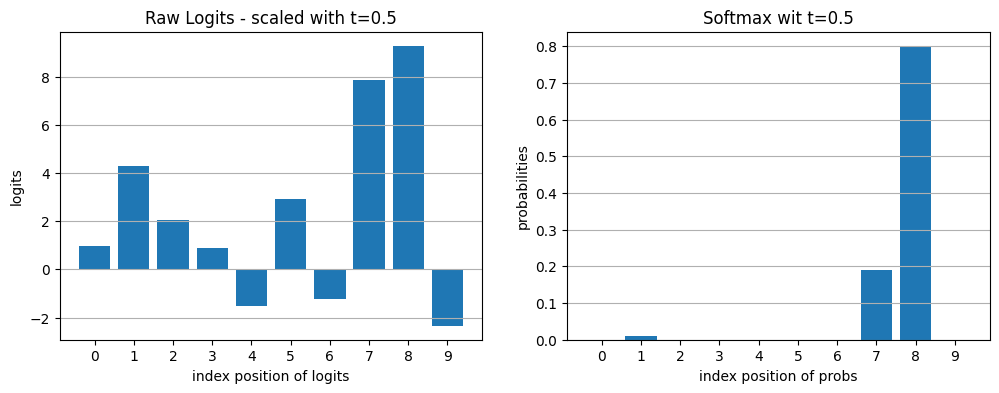

In [19]:
# Plot of the logits and softmax with temperature = 0.5
my_plots(plot1=logits_t, plot2=probs_t, plot1_title=f'Raw Logits - scaled with t={temperature}', plot2_title=f'Softmax wit t={temperature}')

In [20]:
# Let us sample again
np.random.seed(1)
np.random.multinomial(n=20, pvals=probs_t, size=1)

array([[ 0,  0,  0,  0,  0,  0,  0,  5, 15,  0]])

We see it is much sharper in that now, we got 8, 15 times and 7, 5 times. Let's now set the temperature to 2 and see what the results look like. 

In [21]:
# Set a temperature of 0
temperature = 2
logits_t_2 = logits / temperature

print(f'Scaled Logits: {logits_t_2}')
print(f'Original logits: {logits}')

# Get the probabilities
probs_t_2 = softmax(logits_t_2)
print(f'Scaled Probabilities : {probs_t_2.round(2)}')
print(f'original Probabilities : {probs.round(2)}')

Scaled Logits: [ 0.245  1.075  0.515  0.225 -0.38   0.73  -0.31   1.96   2.32  -0.585]
Original logits: [ 0.49  2.15  1.03  0.45 -0.76  1.46 -0.62  3.92  4.64 -1.17]
Scaled Probabilities : [0.04 0.1  0.06 0.04 0.02 0.07 0.03 0.25 0.36 0.02]
original Probabilities : [0.01 0.05 0.02 0.01 0.   0.02 0.   0.29 0.59 0.  ]


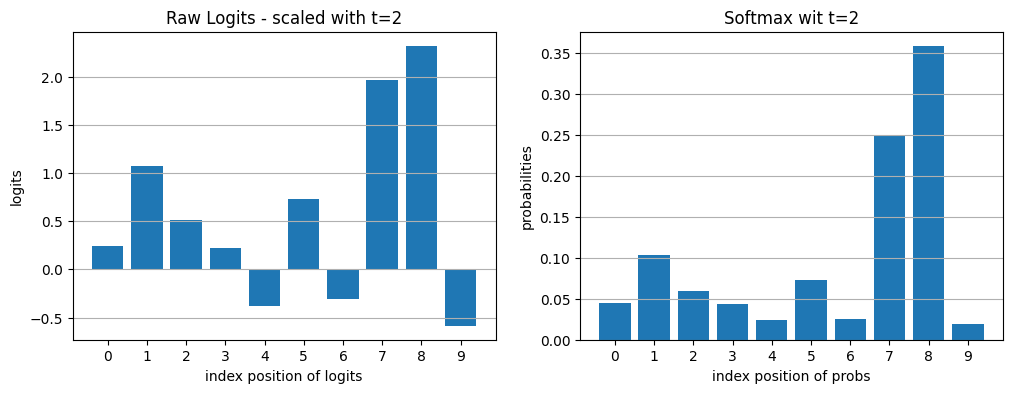

In [22]:
# Plot of the logits and softmax temperature = 2
my_plots(plot1=logits_t_2, plot2=probs_t_2, plot1_title=f'Raw Logits - scaled with t={temperature}', plot2_title=f'Softmax wit t={temperature}')

We see now the probabilities are not as sharp as they were before. The larger the value, the more they are starting to become flatter 
We see when we run the multinomial function again, we have 0 one time, 1, 3 times 7 six times and 8 10 times. This is not as sharp as it was before.

The takeaway we can have is the lower the temperature < 1 the sharper the distribution. Basically, the winner get more. If temperature is greater than 1, the distribution becomes flatter. More equal the chance. 

In [23]:
# Let us sample again
np.random.seed(1)
np.random.multinomial(n=20, pvals=probs_t_2, size=1)

array([[ 1,  3,  0,  0,  0,  0,  0,  6, 10,  0]])

Let us move on to **top_k**    

### top_k   
With top_k, we are sampling from the top k likely probabilities while ignoring all the rest.  
Let us set the top_k here to 3.

In [24]:
# Set top_k=3
top_k = 3

# Get the indices of the largest 3 items
topk_idx = np.argsort(probs)[-top_k:]
print(topk_idx)

# Setup a mask
# Fill the non-top_k positions with -inf
masked = np.full_like(probs, fill_value=-np.inf)
masked[topk_idx] = probs[topk_idx]
print(masked)

# with these new values, let's run Softmax against these probs
masked_probs = softmax(masked)
print(f'Masked probs: {masked_probs}')

[1 7 8]
[-inf 0.05 -inf -inf -inf -inf -inf 0.29 0.59 -inf]
Masked probs: [0.         0.25079904 0.         0.         0.         0.
 0.         0.31882807 0.43037288 0.        ]


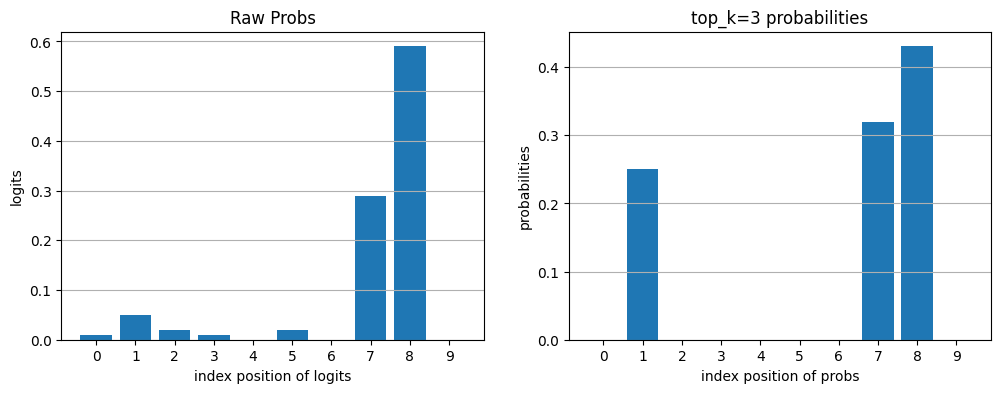

In [25]:
# Let's visualize our normal probabilities
my_plots(plot1=probs, plot2=masked_probs, plot1_title='Raw Probs', plot2_title=f'top_k={top_k} probabilities')

In [26]:
# Let us sample again
np.random.seed(1)
np.random.multinomial(n=20, pvals=masked_probs, size=1)

array([[0, 5, 0, 0, 0, 0, 0, 7, 8, 0]])

We see above, now, when we sampling from our distribution top_k distribution, it is only 3 items we are sampling from. Across the 3 items, the distribution is a lot flatter. Going back to our scenario, if we have 20 bags of 10 items and we pull 1 sample from each bag, we see 8 times we get a 8, 7 times we get an 7 and 5 times we get 1. This is different from what we started off with where we got 8, 15 times out of 20 and 7, 5 times.

Let us now move on to top_p. 

### top_p (Nucleus Sampling)  
With top_p we are not taking the fixed positions but instead taking the cumulative sum of the probabilities that approximates to our top_p. The idea if we take a top_p = 90, then we want the probabilities whose cumulative sum is ~0.90. Similarly, if we take the top_p = 10, we want the probabilities that approximate to 0.10. Our first step is to sort the probabilities in descending order, then extract the items whose cumulative sum is ~0.90.

In [27]:
# define our top_p = .90
top_p = 0.90

# Here is our original probs
print(f'Original probabilities: \n{probs}', end='\n\n')

# Then sort these probabilities
sorted_indices = np.argsort(probs)[::-1]
sorted_probs = probs[sorted_indices]
print(f'Original probabilities: \n{sorted_probs}', end='\n\n')

# Now get the cumulative sum of these sorted probabilities
cum_probs = np.cumsum(sorted_probs)
print(f'Cumsum: {cum_probs}', end='\n\n')

# Get the cut off point
cut_off = np.searchsorted(a=cum_probs, v=top_p)
print(f'Here is the cutoff point: {cut_off}', end='\n\n')

# Let keep only cut off point
top_p_idx = sorted_indices[:cut_off+1]
print(f'top_p={top_p} indicies: {top_p_idx}', end='\n\n')

# Setup the mask like was done before
masked = np.full_like(probs, fill_value=-np.inf)
masked[top_p_idx] = probs[top_p_idx]
print(f'Masked values: {masked}', end='\n\n')

# Run this masked data now through softmax
probs_top_p = softmax(masked)
print(f'top_p_probs: {probs_top_p}')

Original probabilities: 
[0.01 0.05 0.02 0.01 0.   0.02 0.   0.29 0.59 0.  ]

Original probabilities: 
[0.59 0.29 0.05 0.02 0.02 0.01 0.01 0.   0.   0.  ]

Cumsum: [0.59 0.88 0.93 0.95 0.97 0.98 0.99 0.99 0.99 0.99]

Here is the cutoff point: 2

top_p=0.9 indicies: [8 7 1]

Masked values: [-inf 0.05 -inf -inf -inf -inf -inf 0.29 0.59 -inf]

top_p_probs: [0.         0.25079904 0.         0.         0.         0.
 0.         0.31882807 0.43037288 0.        ]


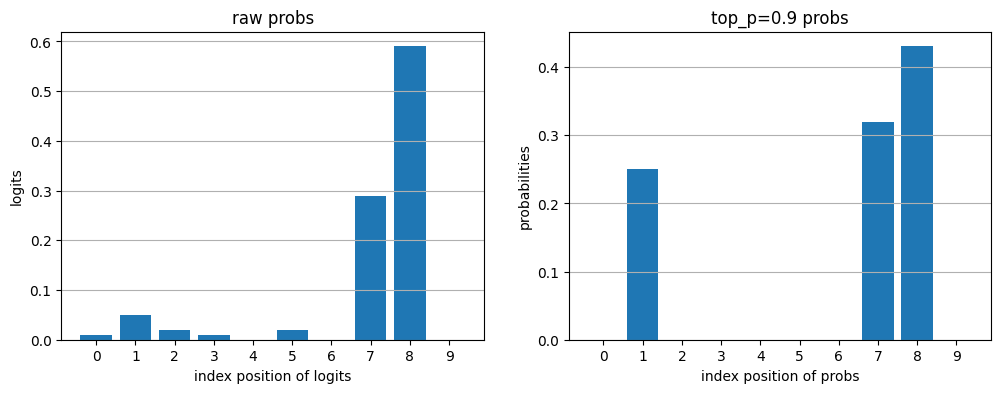

In [28]:
# Let's visualize this again
my_plots(plot1=probs, plot2=probs_top_p, plot1_title='raw probs', plot2_title=f'top_p={top_p} probs')

This plot does not look that different from the top_k. This is just pure coincidence. However, we saw temperature, top_p and top_k. Let's wrap this up these are typically used in conjunction. 

Here is how we put it all together.
1. Start with our logits
2. Apply temperature scaling
3. Convert the logits to probabilities via Softmax
4. Apply top_k filtering
5. Apply top_p filtering
6. Renormzlize (Softmax)
7. Sample

Let us put this entire thing together in a function

In [ ]:
def sample_token(logits, temperature=1.0, top_k=None, top_p=None):
    # if temperature 0, just return the largest logits
    if temperature == 0:
        return np.argmax(logits)
    
    # scale the logits
    logits /= temperature

    # Get the probabilities
    probs = softmax(logits)[-top_k:]

    if top_k is not None:
        idx = np.argsort(probs)
        mask = np.full_like(a=probs, fill_value=-np.inf)
        mask[idx] = probs[idx]
        probs = softmax(probs)

    if top_p is not None:
        idx = np.argsort(probs)[::-1]
        sorted_probs = probs[idx]
        cut_off = np.searchsorted(np.cumsum(sorted_probs), top_p)
        keep = idx[:cut_off + 1]
        mask = np.full_like(probs, fill_value=-np.inf)
        mask[keep] = probs[keep]
        probs = softmax(mask)

    # Sample
    return np.random.multinomial(n=1, pvals=probs)



# Let's sample from here now
#np.random.seed(10)
logits = np.random.uniform(low=-5, high=5, size=(10)).round(2)

# Set the temperature to 0 for this case
sample_token(logits=logits, temperature=0, top_k=3, top_p=0.9)

np.int64(8)

So why did we combine them. Well in real-world LLM usage, you will more than likely take advantage of these hyperparameters. I definitely expect you to be leveraging them if you are building LLM applications. 

Temperature allows for the control of the model's randomness. While top_k allow the model to not focus on irrelevant tokens. while top_p adapts to the shape of the distribution. 